### 10x file preprocessing

This notebook was used to create the 10x dataset used in tutorial 03_training_prediciton. Initial files can be downloaded from the 10x website (https://www.10xgenomics.com/resources/datasets under and the keywords "a new way immune profiling"). It is also an updated form of a notebook from our reproducibility repository of which the resulting dataset was used for the publication (https://github.com/SchubertLab/mvTCR_reproducibility/blob/master/preprocessing/10x_preprocessing.ipynb)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os 
import numpy as np
import scipy as sci
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as pl

import scanpy as sc
import scirpy as ir
import anndata as ann
import awkward as ak

from scipy.sparse import csr_matrix
from matplotlib import rcParams
from matplotlib import colors

e:\Anaconda\envs\mvTCR\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Anaconda\envs\mvTCR\lib\site-packages\airr\schema.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


In [2]:
path_base = r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data\EAE\GSE188320\\"
# path_merged = path_base + 'merged_tcr_10x.h5ad'
# path_filtered = path_base + 'filtered_tcr_10x.h5ad'
# path_logged = path_base + 'logged_10x.h5ad'
# path_highlyvar = path_base + 'highly_var_5000.h5ad'
# path_clean_split = path_base + 'v5_train_val_test.h5ad'
# path_supervised = path_base + 'v6_supervised.h5ad'
path_avidity = path_base + '10x_processed.h5ad'

In [3]:
import muon as mu
# mdata = mu.read("/ihome/ylee/yiz133/Code/Data processing/all_Common_DEtop2500.h5mu")

mdata = mu.read(path_base + "GSE188320_batch6_9_gex_tcr_mvTCR.h5mu")
mdata

e:\Anaconda\envs\mvTCR\lib\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
e:\Anaconda\envs\mvTCR\lib\site-packages\anndata\utils.py:334: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


MuData object with n_obs × n_vars = 39845 × 27998
  2 modalities
    gex:	39845 x 27998
      obs:	'batch', 'condition', 'mouse_id', 'assignment_demuxem'
    airr:	39845 x 0
      obsm:	'airr'

In [ ]:
mdata['gex'].obs['condition']

AAACCTGAGAGTCGGT-1-b6m1    EAE
AAACCTGAGGCTCAGA-1-b6m1    EAE
AAACCTGCAATAGCAA-1-b6m1    EAE
AAACCTGCAGTCTTCC-1-b6m1    EAE
AAACCTGCATTCTTAC-1-b6m1    EAE
                          ... 
TTTGGTTTCGCTTAGA-1-b9m2     UT
TTTGTCAAGTATCTCG-1-b9m2     UT
TTTGTCAGTCGCATCG-1-b9m2     UT
TTTGTCAGTTTGTGTG-1-b9m2     UT
TTTGTCATCCTGCTTG-1-b9m2     UT
Name: condition, Length: 39845, dtype: category
Categories (2, object): ['EAE', 'UT']

In [46]:
adata = mdata['gex']
adata.obsm['airr'] = mdata.mod['airr'].obsm['airr']

adata.obs['mouse_id'].value_counts()

mouse_id
b6m1    8777
b6m2    6235
b7m2    5771
b9m1    5124
b8m1    4552
b8m2    4065
b9m2    3723
b7m1    1598
Name: count, dtype: int64

In [47]:
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log10(adata.obs['n_counts'])

adata.obs['n_genes'] = (adata.X > 0).sum(1)

mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
mt_gene_index = np.where(mt_gene_mask)[0]
adata.obs['mt_fraction'] = adata.X[:, mt_gene_index].sum(1) / adata.X.sum(1)

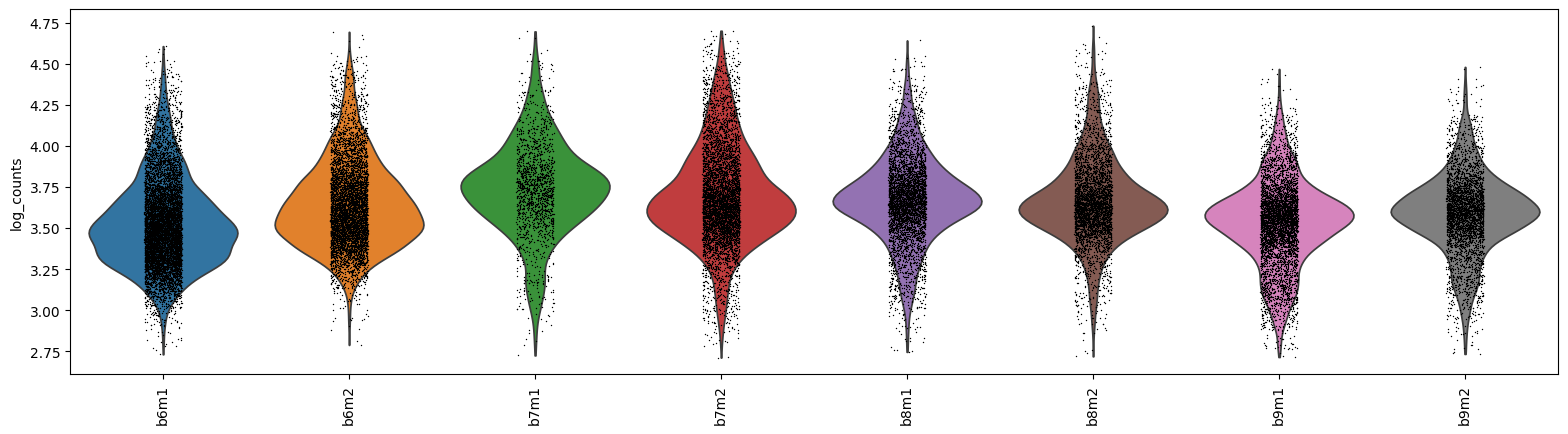

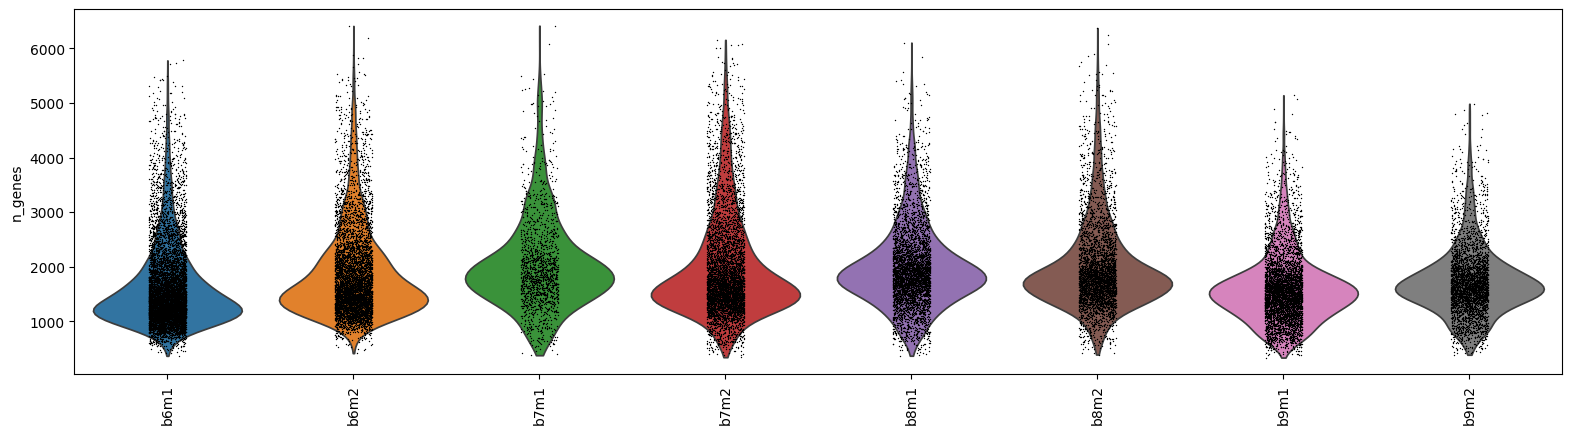

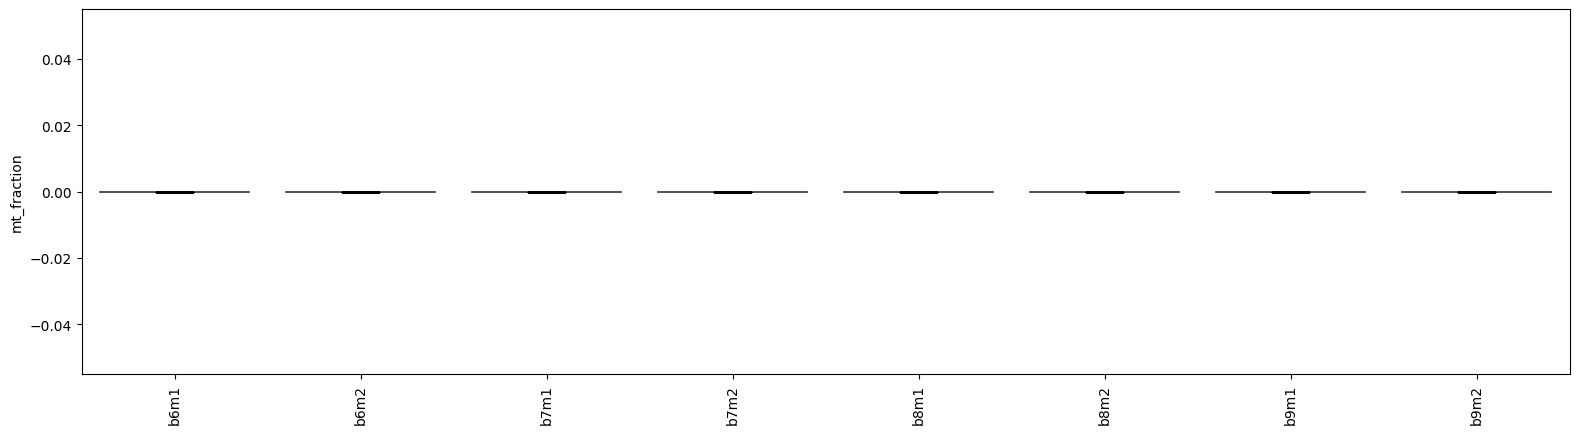

In [48]:
rcParams['figure.figsize'] = (15, 5)
sc.pl.violin(adata, ['log_counts'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata, ['n_genes'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata, ['mt_fraction'], groupby='mouse_id', size=1, log=False, rotation=90)

<Axes: title={'center': 'mt fraction'}, xlabel='n_counts', ylabel='n_genes'>

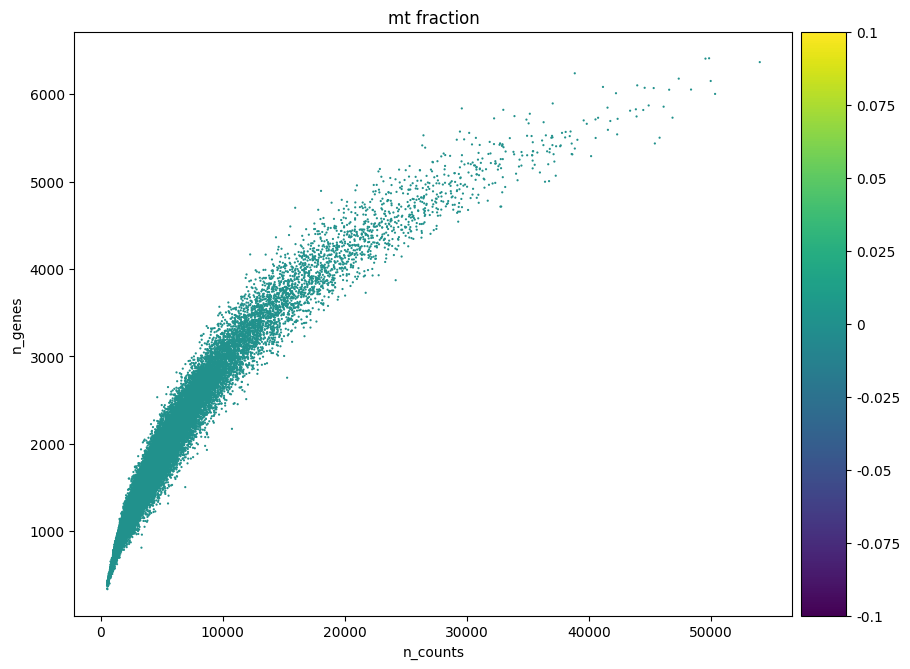

In [49]:
rcParams['figure.figsize'] = (8, 8)
sc.pl.scatter(adata, y='n_genes', x='n_counts', color='mt_fraction', size=10, show=False)

In [50]:
adata_tmp = adata.copy()
print(f'Total number of cells: {adata_tmp.n_obs}')
high_mt = adata_tmp.obs['mt_fraction'] < 0.2  #todo why this value
adata_tmp = adata_tmp[high_mt]
print(f'Number of cells after MT filter: {adata_tmp.n_obs}')

Total number of cells: 39845
Number of cells after MT filter: 39845


In [51]:
low_count = adata_tmp.obs['n_counts'] > 1000
adata_tmp = adata_tmp[low_count]
print(f'Number of cells after minimum count filter: {adata_tmp.n_obs}')

sc.pp.filter_cells(adata_tmp, max_counts=10000)
print(f'Number of cells after maximum filter: {adata_tmp.n_obs}')

Number of cells after minimum count filter: 39389


e:\Anaconda\envs\mvTCR\lib\site-packages\scanpy\preprocessing\_simple.py:137: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number


Number of cells after maximum filter: 35835


In [52]:
low_genes = adata_tmp.obs['n_genes'] > 500
adata_tmp = adata_tmp[low_genes]
print(f'Number of cells after minimum gene filter: {adata_tmp.n_obs}')

Number of cells after minimum gene filter: 35835


In [53]:
sc.pp.filter_genes(adata_tmp, min_cells=10)
print(f'Number of cells after gene filter: {adata_tmp.n_vars}')

e:\Anaconda\envs\mvTCR\lib\site-packages\scanpy\preprocessing\_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number


Number of cells after gene filter: 14358


In [54]:
import scrublet as scr
import scipy.io
import time

In [55]:
adata_tmp.obs['doublet_score'] = np.zeros(adata_tmp.shape[0])
adata_tmp.obs['doublet'] = np.zeros(adata_tmp.shape[0])

In [56]:
# filtering / preprocessing parameters:
min_counts = 2
min_cells = 3
vscore_percentile = 85
n_pc = 50

# doublet detector parameters
expected_doublet_rate = 0.02
sim_doublet_ratio = 3
n_neighbors = 15

for batch in enumerate(adata_tmp.obs['mouse_id'].cat.categories):
    print(batch)
    t0 = time.time()
    idx = np.flatnonzero(adata_tmp.obs['mouse_id']==batch[1])
    scrub = scr.Scrublet(counts_matrix = adata_tmp[idx, :].X,
                        n_neighbors = n_neighbors,
                        sim_doublet_ratio = sim_doublet_ratio,
                        expected_doublet_rate = expected_doublet_rate)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts = min_counts,
                                                              min_cells = min_cells,
                                                              n_prin_comps = n_pc,
                                                              use_approx_neighbors = True,
                                                              get_doublet_neighbor_parents = False)
    adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores
    adata_tmp.obs['doublet'].iloc[idx] = predicted_doublets
    t1 = time.time()
    print('Elapsed time: {:.1f} seconds'.format(t1-t0))

(0, 'b6m1')
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.15
Detected doublet rate = 1.8%
Estimated detectable doublet fraction = 10.6%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 16.9%
Elapsed time: 5.9 seconds
Elapsed time: 6.2 seconds
(1, 'b6m2')


C:\Users\a4945\AppData\Local\Temp\ipykernel_1940\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores
C:\Users\a4945\AppData\Local\Temp\ipykernel_1940\3502024312.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet'].iloc[idx] = predicted_doublets


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.15
Detected doublet rate = 1.5%
Estimated detectable doublet fraction = 12.6%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 12.0%
Elapsed time: 9.8 seconds
Elapsed time: 10.7 seconds
(2, 'b7m1')
Preprocessing...


C:\Users\a4945\AppData\Local\Temp\ipykernel_1940\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 2.1%
Estimated detectable doublet fraction = 11.3%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 18.7%
Elapsed time: 2.5 seconds
Elapsed time: 2.7 seconds
(3, 'b7m2')


...

C:\Users\a4945\AppData\Local\Temp\ipykernel_1940\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.15
Detected doublet rate = 1.5%
Estimated detectable doublet fraction = 12.2%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 12.5%
Elapsed time: 10.0 seconds
Elapsed time: 10.5 seconds
(7, 'b9m2')


C:\Users\a4945\AppData\Local\Temp\ipykernel_1940\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 2.3%
Estimated detectable doublet fraction = 14.9%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 15.5%
Elapsed time: 6.8 seconds
Elapsed time: 7.2 seconds


C:\Users\a4945\AppData\Local\Temp\ipykernel_1940\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


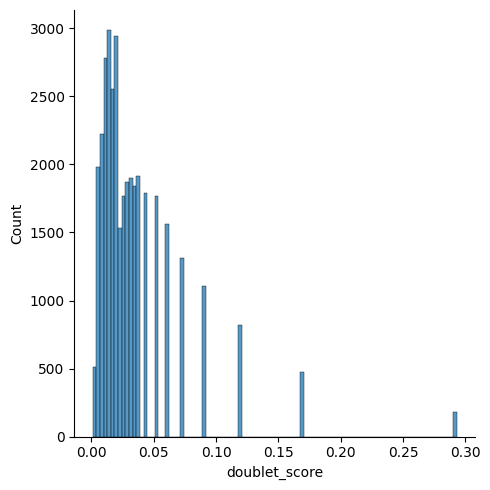

In [57]:
rcParams['figure.figsize'] = (6, 6)
sb.displot(adata_tmp.obs['doublet_score'], bins=100, kde=False)

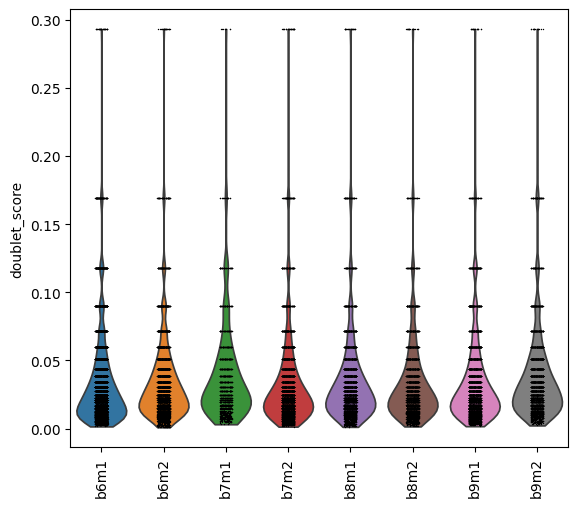

In [58]:
sc.pl.violin(adata_tmp, ['doublet_score'], groupby='mouse_id', size=1, log=False, rotation=90)

In [59]:
thr = 0.05
idx_filter = adata_tmp.obs['doublet_score'] <= thr

adata_tmp = adata_tmp[idx_filter].copy()
print(f'Number of cells after double filter: {adata_tmp.n_obs}')

Number of cells after double filter: 28608


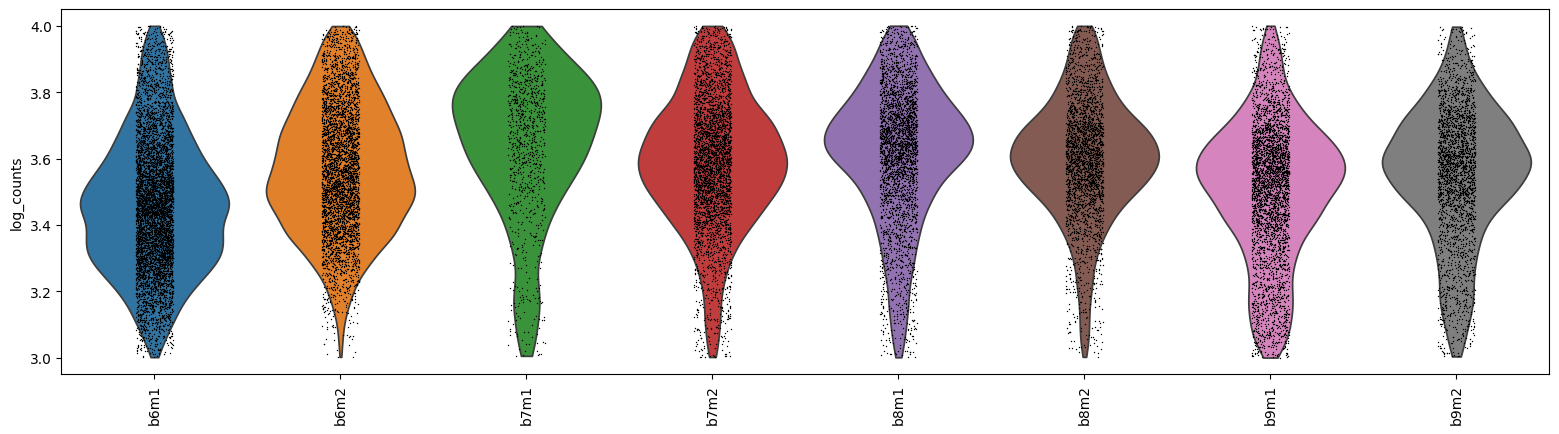

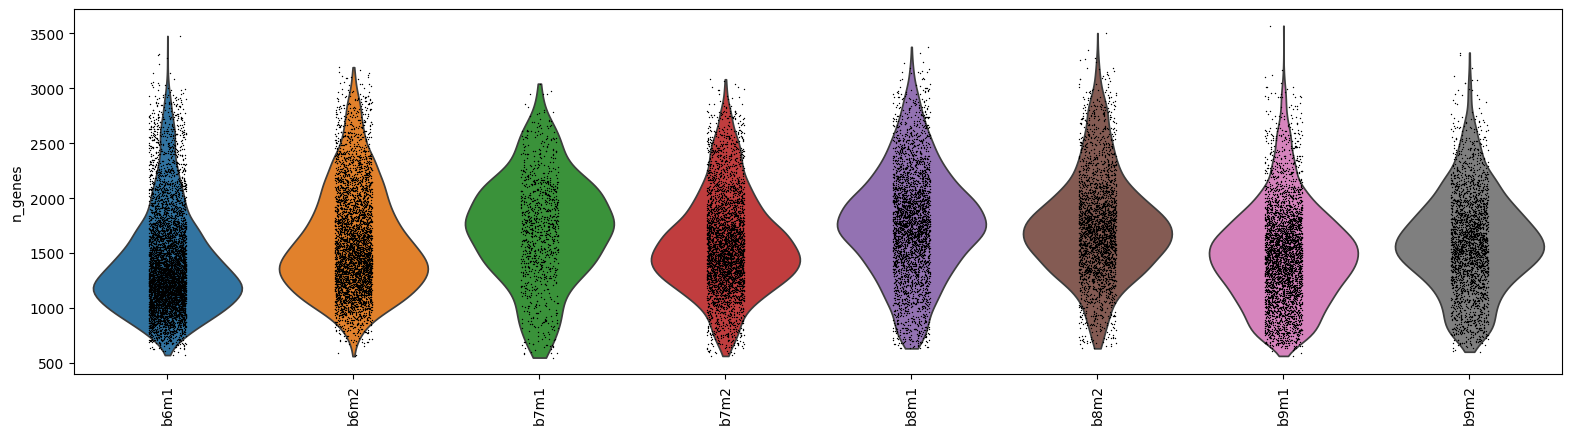

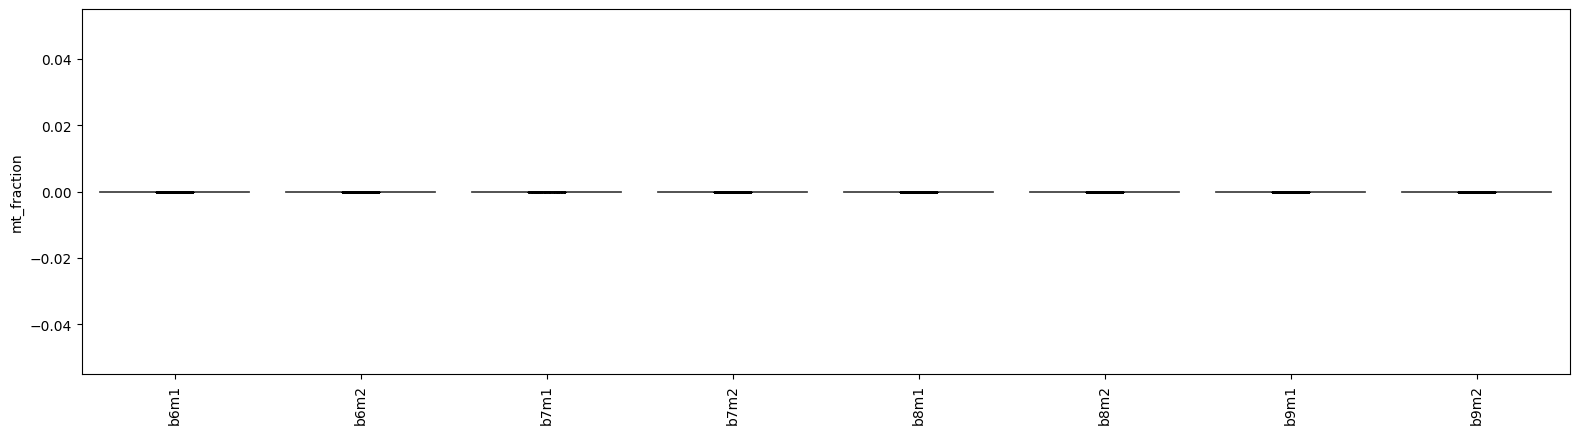

In [60]:
rcParams['figure.figsize'] = (15, 5)
sc.pl.violin(adata_tmp, ['log_counts'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata_tmp, ['n_genes'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata_tmp, ['mt_fraction'], groupby='mouse_id', size=1, log=False, rotation=90)

In [61]:
df = adata_tmp.obs[['n_genes', 'n_counts', 'mouse_id']]
df_all = pd.DataFrame(df.groupby(by='mouse_id')['n_genes'].apply(np.mean).values, 
                      index=df.groupby(by='mouse_id')['n_genes'].apply(np.mean).index, 
                      columns=['mean_genes'])

df_all['median_genes'] = df.groupby(by='mouse_id')['n_genes'].apply(np.median).values
df_all['mean_counts'] = df.groupby(by='mouse_id')['n_counts'].apply(np.mean).values
df_all['median_counts'] = df.groupby(by='mouse_id')['n_counts'].apply(np.median).values
df_all

,mean_genes,median_genes,mean_counts,median_counts
mouse_id,,,,
b6m1,1414.523247,1309.0,3244.445801,2815.0
b6m2,1608.572811,1515.0,4081.624512,3617.0
b7m1,1722.428138,1744.5,4901.983887,4829.0
b7m2,1590.463153,1531.0,4273.011230,3913.5
b8m1,1770.970838,1768.0,4527.906250,4379.5
b8m2,1745.915191,1706.0,4321.439941,4048.0
b9m1,1485.131203,1467.0,3578.210693,3409.0
b9m2,1595.686355,1583.0,3931.287842,3775.0


In [62]:
adata_tmp.obs['doublet'] = adata_tmp.obs['doublet'].astype(str)

In [63]:
# sc.write(adata=adata_tmp, filename=path_filtered)

In [64]:
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)

In [65]:
# sc.write(adata=adata_tmp, filename=path_logged)

In [66]:
adata_tmp.uns['log1p'] = {'base': None}
sc.pp.highly_variable_genes(adata_tmp, n_top_genes=2500, batch_key='mouse_id')
print('Shape before: ', adata_tmp.shape)
adata = adata_tmp[:, adata_tmp.var['highly_variable']]
print('Shape after:  ', adata.shape)

Shape before:  (28608, 14358)
Shape after:   (28608, 2500)


In [ ]:
# sc.write(adata=adata, filename=path_highlyvar)

NameError: name 'path_highlyvar' is not defined

In [68]:
ir.pp.index_chains(adata)
ir.tl.chain_qc(adata)

# by nucleotide acid seq
ir.pp.ir_dist(adata)
ir.tl.define_clonotypes(adata, receptor_arms="all", dual_ir="primary_only")

100%|██████████| 6/6 [00:20<00:00,  3.49s/it]
e:\Anaconda\envs\mvTCR\lib\site-packages\scirpy\pp\_index_chains.py:127: ImplicitModificationWarning: Setting element `.obsm['chain_indices']` of view, initializing view as actual.
  params.adata.obsm[key_added] = chain_index_awk  # type: ignore
100%|██████████| 11358/11358 [00:22<00:00, 500.36it/s]


In [69]:
junction_aa = ir.get.airr(adata, "junction_aa")
cells_with_both_chains = ~(junction_aa['VJ_1_junction_aa'].isna() | junction_aa['VDJ_1_junction_aa'].isna())
print(adata.shape)
adata = adata[cells_with_both_chains]
print(adata.shape)

(28608, 2500)
(22497, 2500)


In [70]:
from mvtcr.utils_preprocessing import Preprocessing

In [71]:
Preprocessing.check_if_valid_adata(adata)

True

In [72]:
Preprocessing.encode_clonotypes(adata)

100%|██████████| 8523/8523 [00:06<00:00, 1347.50it/s]


In [73]:
Preprocessing.encode_tcr(adata, airr_name='junction_aa', 
               alpha_label_key='alpha_seq', alpha_length_key='alpha_len',
               beta_label_key='beta_seq', beta_length_key='beta_len')

In [74]:
antigen_binding_list = [x for x in adata.obs.columns if x.endswith('_binder')]
len(antigen_binding_list)

0

In [75]:
binding_matrix = (adata.obs[antigen_binding_list] == 'True').values.astype(int)
binding_matrix.shape

(22497, 0)

In [76]:
unique_value, count = np.unique(binding_matrix.sum(axis=1), return_counts=True)
for unique_value_, count_ in zip(unique_value, count):
    print(f'Cells with {unique_value_} bindings: {count_}')

Cells with 0 bindings: 22497


In [77]:
label_to_binding = {label_id: antigen for label_id, antigen in enumerate(antigen_binding_list)}
label_to_binding[-1] = 'no_data'  # For cells without binding data
binding_to_label = {antigen: label_id for label_id, antigen in enumerate(antigen_binding_list)}
binding_to_label['no_data'] = -1
binding_to_label == {v: k for k, v in label_to_binding.items()}  # sanity check, if both dicts are the reverse of each other

True

In [78]:
adata.obs['has_binding'] = binding_matrix.sum(axis=1).astype(bool)
adata.obs['has_binding'].head()

AAACCTGAGGCTCAGA-1-b6m1    False
AAACCTGCAATAGCAA-1-b6m1    False
AAACCTGCAGTCTTCC-1-b6m1    False
AAACCTGCATTCTTAC-1-b6m1    False
AAACCTGGTACATCCA-1-b6m1    False
Name: has_binding, dtype: bool

In [79]:
random_seed = 15
# Create Train-Val and Test set
train_val, test = Preprocessing.stratified_group_shuffle_split(adata, stratify_col='mouse_id', group_col='clonotype', test_size=0.2, random_seed=random_seed)
# Split Train-Val into Train and Val set
train, val = Preprocessing.stratified_group_shuffle_split(adata[train_val], stratify_col='mouse_id', group_col='clonotype', test_size=0.25, random_seed=random_seed)

100%|██████████| 8/8 [00:00<00:00, 257.40it/s]


In [80]:
print('Train Samples: ', len(train))
print('Train Ratio: ', len(train) / len(adata.obs))
print('Val Samples: ', len(val))
print('Val Ratio: ', len(val) / len(adata.obs))
print('Test Samples: ', len(test))
print('Test Ratio: ', len(test) / len(adata.obs))

Train Samples:  13514
Train Ratio:  0.6007023158643374
Val Samples:  4408
Val Ratio:  0.19593723607592123
Test Samples:  4575
Test Ratio:  0.2033604480597413


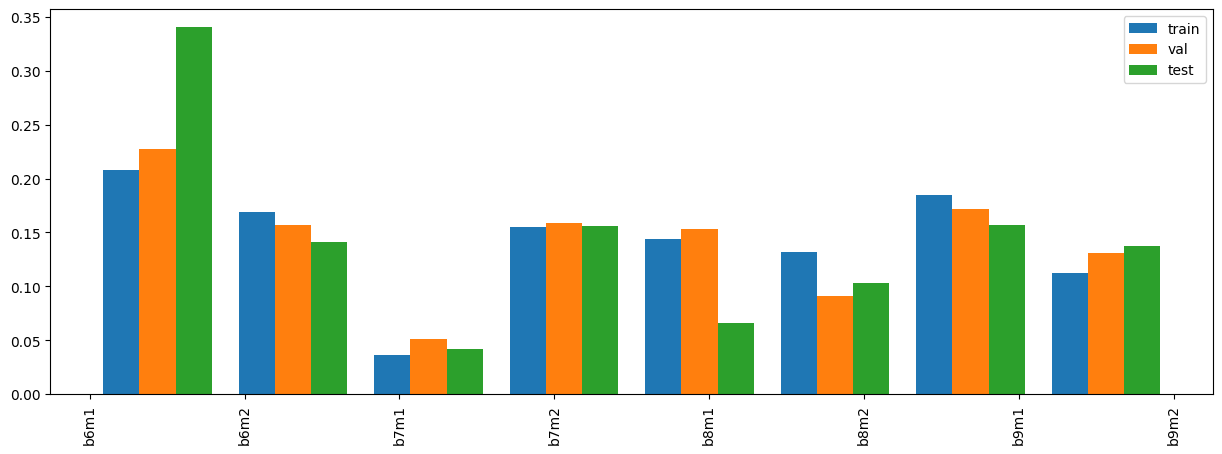

In [81]:
pl.figure(figsize=(15,5))
pl.hist([adata.obs.loc[train]["mouse_id"], adata.obs.loc[val]["mouse_id"], adata.obs.loc[test]["mouse_id"]], density=True, bins=len(adata.obs.loc[train]["mouse_id"].unique()), label=['train', 'val', 'test'])
pl.xticks(rotation='vertical')
pl.legend(loc='upper right')
pl.show()

In [82]:
form_train = set(adata.obs.loc[train]['clonotype'].tolist())
form_val = set(adata.obs.loc[val]['clonotype'].tolist())
form_test = set(adata.obs.loc[test]['clonotype'].tolist())

print('Intersection in clonotypes between two sets should be empty\n')
print('Intersection in clonotypes between train and test: ', form_train.intersection(form_test))
print('Intersection in clonotypes between train and val: ', form_train.intersection(form_val))
print('Intersection in clonotypes between val and test: ', form_val.intersection(form_test))
# print('\nSanity Check - Intersection in clonotypes between train and train: ', form_train.intersection(form_train))

Intersection in clonotypes between two sets should be empty

Intersection in clonotypes between train and test:  set()
Intersection in clonotypes between train and val:  set()
Intersection in clonotypes between val and test:  set()


In [83]:
adata.obs.loc[train, 'set'] = 'train'
adata.obs.loc[val, 'set'] = 'val'
adata.obs.loc[test, 'set'] = 'test'
adata.obs['set'].value_counts()

set
train    13514
test      4575
val       4408
Name: count, dtype: int64

In [84]:
adata.obs['set'].sample(20)

ACGGGCTTCCACGTTC-1-b6m1      val
GCAGCCATCTTATCTG-1-b6m2    train
TGGCTGGAGGCCATAG-1-b6m2      val
GCGCCAAGTAGCCTAT-1-b8m2    train
TATCTCAAGTAGTGCG-1-b8m2    train
AGTGGGACACCTGGTG-1-b9m1    train
TGTATTCCAGCATGAG-1-b6m1      val
ACGGAGAAGGGAAACA-1-b7m2    train
TTCTACAAGCAGACTG-1-b6m1    train
TGCGCAGGTCACTTCC-1-b6m1    train
CTAGTGATCTGACCTC-1-b6m2    train
CGTTCTGTCCAAAGTC-1-b6m1    train
CATTATCAGTTAACGA-1-b9m1      val
CACCAGGCAAGTCTGT-1-b6m1    train
ATCCACCGTGCAGTAG-1-b6m1    train
GGCGACTCAGCCTTGG-1-b8m1    train
CAGTCCTCATAAGACA-1-b6m1    train
TAGACCACACCTATCC-1-b6m2    train
AGAATAGAGAAACCTA-1-b7m2      val
TCATTACAGTACGTAA-1-b8m1    train
Name: set, dtype: object

In [85]:
# adata.write_h5ad(path_clean_split, compression='gzip')

In [86]:
Preprocessing.check_if_valid_adata(adata)

True

In [87]:
# import config.constants_10x as constants
# high_count_antigens = constants.HIGH_COUNT_ANTIGENS.copy()
# high_count_antigens

In [88]:
# sc.write(adata=adata, filename=path_supervised)

In [89]:
# Preprocessing.check_if_valid_adata(adata)

In [90]:
sc.write(adata=adata, filename=path_avidity)

In [91]:
adata

AnnData object with n_obs × n_vars = 22497 × 2500
    obs: 'batch', 'condition', 'mouse_id', 'assignment_demuxem', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'has_binding', 'set'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'mouse_id_colors', 'log1p', 'hvg', 'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype', 'aa_to_id'
    obsm: 'airr', 'chain_indices', 'alpha_seq', 'beta_seq'